# Course project

This notebook includes the code for the course project in the DTU course [Integrated Energy Grids](https://kurser.dtu.dk/course/2024-2025/46770?menulanguage=en)  and is modelling and analyzing the german energy system. 
 
The report is provided along this notebook, further explaining the results. 

### Imports

In [2]:
import pandas as pd
import pypsa
import matplotlib.pyplot as plt
import numpy as np

In [3]:
import os
import sys

# Set path to the directory containing base.py
module_path = os.path.abspath(".")

if module_path not in sys.path:
    sys.path.append(module_path)

import base  # now you can use base.build_network()

from visualization import *

In [4]:
country = "DEU"

### Importing Germany Heating Data

Important: when2heat data must be downloaded from here: https://data.open-power-system-data.org/when2heat/

In [ ]:
DE_heat_list = ['DE_heat_demand_space', 'DE_COP_ASHP_radiator']

when2heat = pd.read_csv('data/when2heat.csv',sep=';')
when2heat.index = pd.DatetimeIndex(when2heat['utc_timestamp'])
DE_heat = when2heat[DE_heat_list].loc["2015"]

DE_heat["DE_COP_ASHP_radiator"] = DE_heat["DE_COP_ASHP_radiator"].astype(str).str.replace(",", ".", regex=False).astype(float)
DE_heat.head()


In [15]:
heating_demand = DE_heat["DE_heat_demand_space"]

In [16]:
cop = DE_heat["DE_COP_ASHP_radiator"]

In [17]:
# Pad with last value if shorter than 8760
if len(heating_demand) < 8760:
    last_value = heating_demand.iloc[-1]
    pad_length = 8760 - len(heating_demand)
    padding = pd.Series([last_value] * pad_length, index=pd.date_range(
        start=heating_demand.index[-1] + pd.Timedelta(hours=1),
        periods=pad_length,
        freq="H",
        tz=heating_demand.index.tz  # Preserve timezone
    ))

heating_demand = pd.concat([heating_demand, padding])

# Pad with last value if shorter than 8760
if len(cop) < 8760:
    last_value = cop.iloc[-1]
    pad_length = 8760 - len(cop)
    padding = pd.Series([last_value] * pad_length, index=pd.date_range(
        start=cop.index[-1] + pd.Timedelta(hours=1),
        periods=pad_length,
        freq="H",
        tz=cop.index.tz  # Preserve timezone
    ))

cop = pd.concat([cop, padding])

C:\Users\mario\AppData\Local\Temp\ipykernel_13200\2799647686.py:5: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  padding = pd.Series([last_value] * pad_length, index=pd.date_range(
C:\Users\mario\AppData\Local\Temp\ipykernel_13200\2799647686.py:18: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  padding = pd.Series([last_value] * pad_length, index=pd.date_range(


## G. Sector Coupling 
Connect the electricity sector with, at least, another sector( e.g. heating or transport), and co-optimize all the sectors. Discuss your results.

In [18]:
network = base.build_network(solve=False)

c:\Users\mario\001_PROJ\Space\00X Studies\009 Integrated energy grids\46770_IEG\base.py:30: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_daily["Inflow [MW]"] = df_daily["Inflow [GWh]"] * 1000 / 24  # MW average per hour


In [19]:
network.add("Bus", "heat")


Index(['heat'], dtype='object')

<Axes: xlabel='snapshot', ylabel='MW'>

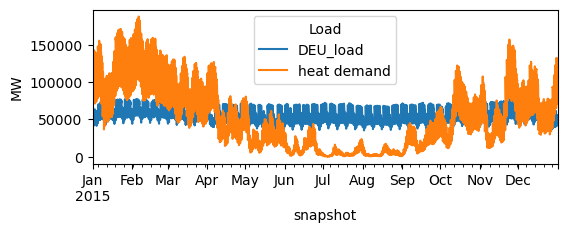

In [21]:
# add load to the bus
network.add("Load",
      "heat demand",
      bus="heat",
      p_set=heating_demand.values)

network.loads_t.p_set.plot(figsize=(6, 2), ylabel="MW")

In [22]:
costs = base.load_technology_data()
network.add(
    "StorageUnit",
    "battery storage",
    bus=f"{country}_elec",
    carrier="battery storage",
    max_hours=2,
    capital_cost=costs.at["battery inverter", "capital_cost"]
    + 2 * costs.at["battery storage", "capital_cost"],
    efficiency_store=costs.at["battery inverter", "efficiency"],
    efficiency_dispatch=costs.at["battery inverter", "efficiency"],
    p_nom_extendable=True,
    cyclic_state_of_charge=True,
)

Index(['battery storage'], dtype='object')

We add now the CHP unit assuming a constant efficiency for power and heat generator using a multilink and a store of gas with unlimited capacity

In [23]:
network.add("Bus", "gas")

# We add a gas store with energy capacity and an initial filling level much higher than the required gas consumption, 
# this way gas supply is unlimited
network.add("Store", "gas", e_initial=1e6, e_nom=1e6, bus="gas") 

network.add(
    "Link",
    "CHP",
    bus0="gas",
    bus1=f"{country}_elec",
    bus2="heat",
    p_nom_extendable=True,
    #p_nom=1000,
    marginal_cost=80,
    efficiency=0.4,
    efficiency2=0.4,
)

Index(['CHP'], dtype='object')

We add the heat pump to the network and plot to check that it was propoerly added. 

<Axes: xlabel='snapshot', ylabel='COP'>

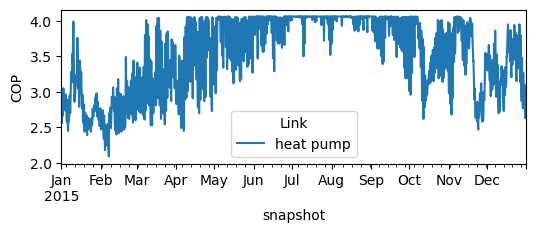

In [24]:
network.add(
    "Link",
    "heat pump",
    carrier="heat pump",
    bus0=f"{country}_elec",
    bus1="heat",
    efficiency=cop.values,
    p_nom_extendable=True,
    capital_cost=costs.at["central air-sourced heat pump", "capital_cost"],  # €/MWe/a
)

network.links_t.efficiency.plot(figsize=(6, 2), ylabel="COP")

In [25]:
network.optimize(solver_name="highs")

Index(['CHP', 'heat pump'], dtype='object', name='Link')


Index(['gas'], dtype='object', name='Store')
Index(['DEU_elec', 'heat', 'gas'], dtype='object', name='Bus')
Index(['battery storage'], dtype='object', name='StorageUnit')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 10/10 [00:00<00:00, 53.60it/s]
INFO:linopy.io: Writing time: 1.37s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 131411 primals, 289096 duals
Objective: 8.15e+10
Solver model: available
Solver message: optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, Store-fix-e-lower, Store-fix-e-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, StorageUnit-ext-p_store-upper, StorageUnit-ext-state_of_charge-lower, StorageUnit-ext-state_of_charge-upper, StorageUnit-energy_balance, Sto

('ok', 'optimal')

System Cost: 81.48 billion euros

Optimal Generator and Storage Capacities (GW):
coal                26.000000
lignite             21.000000
biomass CHP         10.000000
OCGT                31.000000
ror                  6.000000
onwind             109.886221
offwind             10.706700
solar              285.596159
battery storage    148.930806
Name: p_nom_opt, dtype: float64

Optimal Annual Energy Generation (GWh):
coal                94.939289
lignite             99.228291
biomass CHP         48.034908
OCGT                63.147971
ror                 16.444508
onwind              98.939669
offwind             26.404308
solar              222.184212
battery storage     -7.746389
dtype: float64


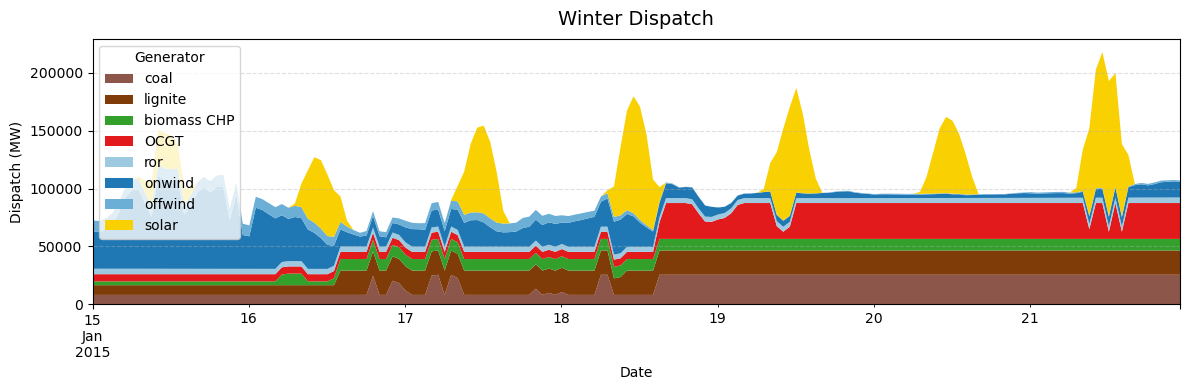

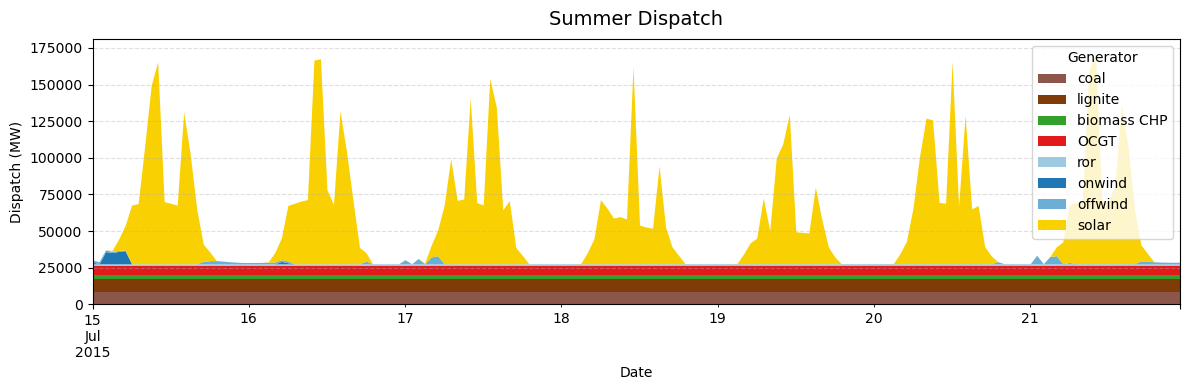

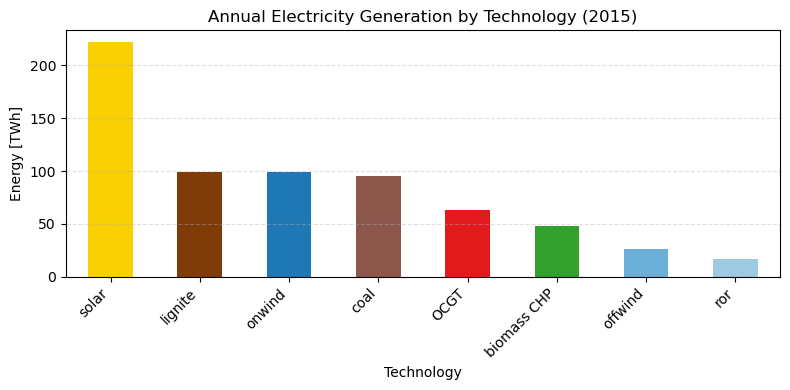

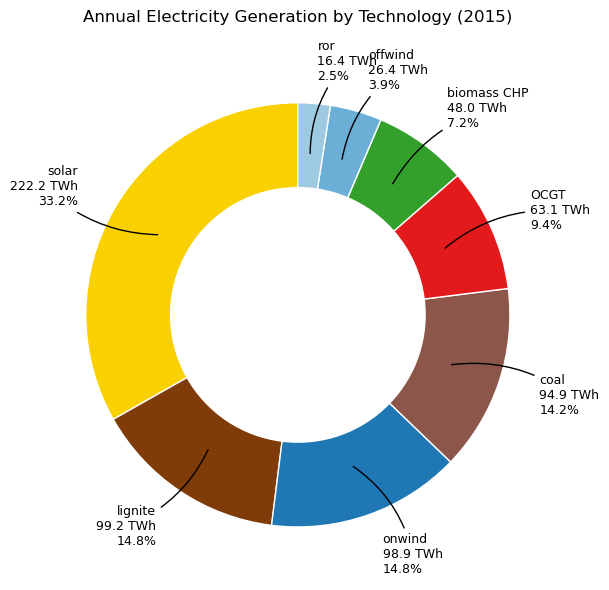

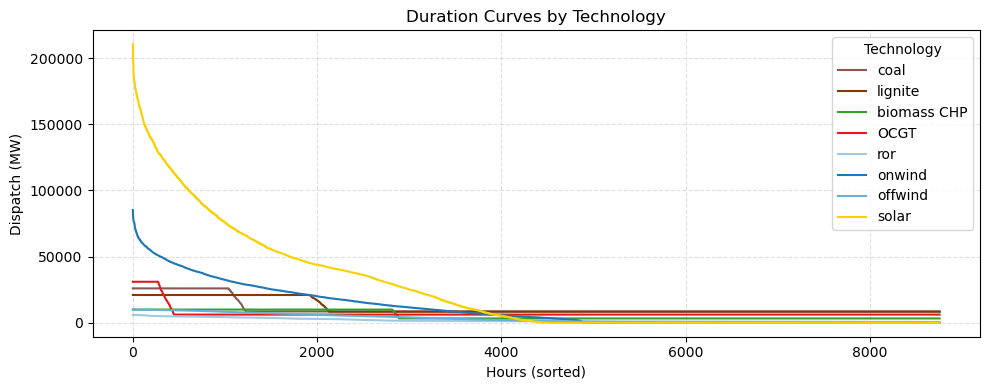

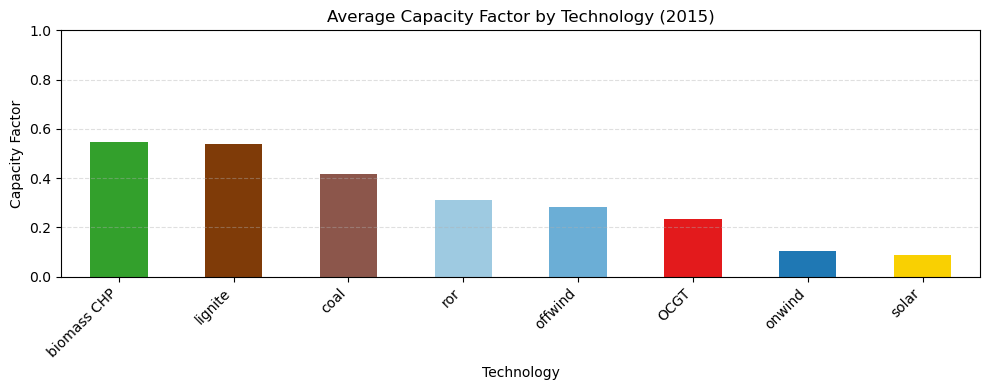

In [27]:
print_summary(network)
# Plot winter week
plot_dispatch_week(network, "2015-01-15", "2015-01-21", "Winter Dispatch")
# Plot summer week
plot_dispatch_week(network,"2015-07-15", "2015-07-21", "Summer Dispatch")
plot_generation_bar(network)
plot_generation_pie(network)
plot_duration_curves(network)
plot_capacity_factors(network)

In [29]:
network.objective / 1e9

81.48315922475918

The optimised capacities in GW, notice that we are representing some technologies using generators componenets and other using heat components, so we need to check both.

In [30]:
network.generators.p_nom_opt.div(1e3)  # MW -> GW

Generator
coal            26.000000
lignite         21.000000
biomass CHP     10.000000
OCGT            31.000000
ror              6.000000
onwind         109.886221
offwind         10.706700
solar          285.596159
Name: p_nom_opt, dtype: float64

In [53]:
network.links.p_nom_opt.div(1e3)

Link
CHP          92.13384
heat pump    83.48756
Name: p_nom_opt, dtype: float64

The total energy generation by technology in TWh:

In [54]:
network.generators_t.p.sum().div(1e6)  # MWh -> TWh

Generator
coal            94.939289
lignite         99.228291
biomass CHP     48.034908
OCGT            63.147971
ror             16.444508
onwind          98.939669
offwind         26.404308
solar          222.184212
dtype: float64

Electricity generation CHP

In [34]:
-network.links_t.p1['CHP'].sum()*0.000001  # MWh -> TWh

0.4

Heat generation from CHP and heat pumps

In [35]:
-network.links_t.p2['CHP'].sum()*0.000001  # MWh -> TWh

0.4

In [36]:
-network.links_t.p1['heat pump'].sum()*0.000001  # MWh -> TWh

482.541639

We can plot the dispatch of electricity from every generator throughout January

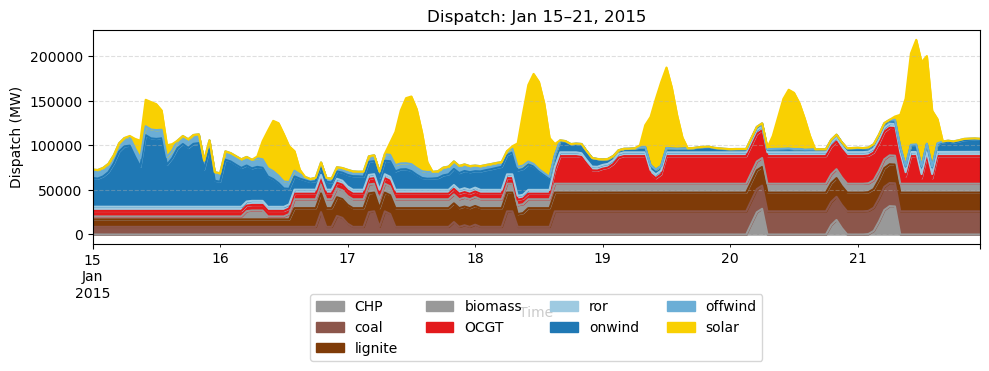

In [49]:
# Define the week
week1 = slice("2015-01-15", "2015-01-21")

# Extract data for the week
dispatch_w1 = pd.concat([
    -network.links_t.p1['CHP'].loc[week1],
    network.generators_t.p.loc[week1]
], axis=1).rename(columns={"biomass CHP": "biomass"})

# Ensure consistent column order and assign colors
columns = dispatch_w1.columns
colors = [color_map.get(col, "#999999") for col in columns]

# Plot
fig, ax = plt.subplots(figsize=(10, 4))
dispatch_w1.plot.area(ax=ax, color=colors)
ax.set_title("Dispatch: Jan 15–21, 2015")
ax.set_ylabel("Dispatch (MW)")
ax.set_xlabel("Time")
ax.grid(axis="y", linestyle="--", alpha=0.4)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=4)

plt.tight_layout()
plt.show()


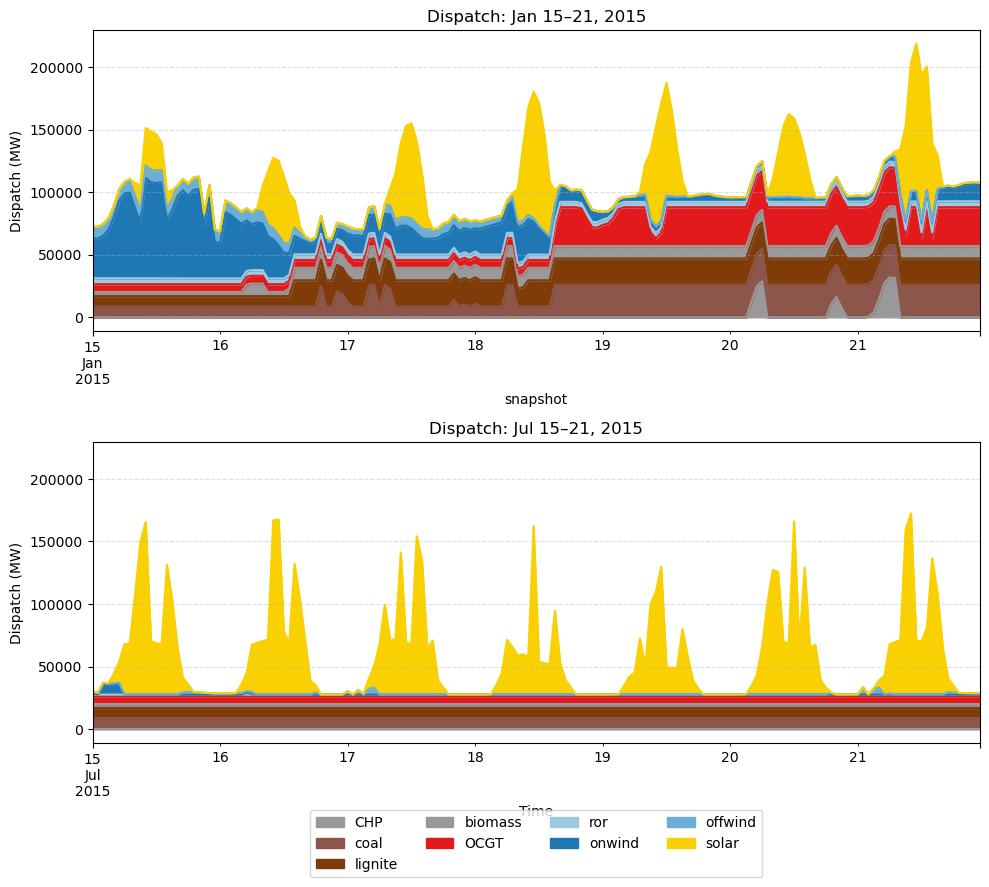

In [43]:
# Define the two weeks
week1 = slice("2015-01-15", "2015-01-21")
week2 = slice("2015-07-15", "2015-07-21")

# Extract data for both weeks
dispatch_w1 = pd.concat([
    -network.links_t.p1['CHP'].loc[week1],
    network.generators_t.p.loc[week1]
], axis=1).rename(columns={"biomass CHP": "biomass"})

dispatch_w2 = pd.concat([
    -network.links_t.p1['CHP'].loc[week2],
    network.generators_t.p.loc[week2]
], axis=1).rename(columns={"biomass CHP": "biomass"})

# Ensure consistent column order and colors
columns = dispatch_w1.columns.union(dispatch_w2.columns)
dispatch_w1 = dispatch_w1.reindex(columns=columns, fill_value=0)
dispatch_w2 = dispatch_w2.reindex(columns=columns, fill_value=0)
colors = [color_map.get(col, "#999999") for col in columns]

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 9), sharey=True)

dispatch_w1.plot.area(ax=ax1, color=colors)
ax1.set_title("Dispatch: Jan 15–21, 2015")
ax1.set_ylabel("Dispatch (MW)")
ax1.grid(axis="y", linestyle="--", alpha=0.4)
ax1.legend().remove()

dispatch_w2.plot.area(ax=ax2, color=colors)
ax2.set_title("Dispatch: Jul 15–21, 2015")
ax2.set_ylabel("Dispatch (MW)")
ax2.set_xlabel("Time")
ax2.grid(axis="y", linestyle="--", alpha=0.4)
ax2.legend(loc="upper center", bbox_to_anchor=(0.5, -0.2), ncol=4)

plt.tight_layout()
plt.show()


We can also plot the dispatch of heating from every generator throughout January

<Axes: xlabel='snapshot', ylabel='dispatch'>

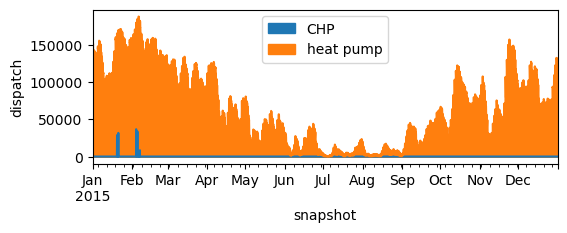

In [52]:
pd.concat([-network.links_t.p2['CHP'].loc["2015"],-network.links_t.p1['heat pump'].loc["2015"]], axis=1).plot.area(figsize=(6, 2), ylabel="dispatch")

We can also plot the annual electricity mix and heating mix

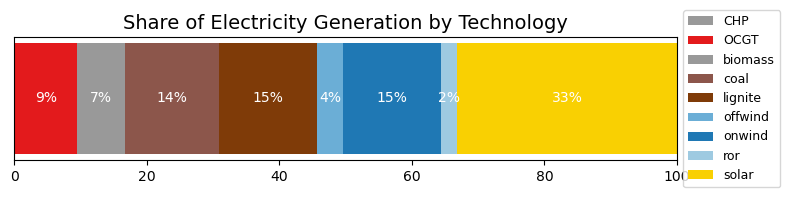

In [50]:
# Combine and sum total dispatch
dispatch_total = pd.concat([
    -network.links_t.p1['CHP'],  # negative because p1 is output from grid's perspective
    network.generators_t.p
], axis=1).sum().rename({"biomass CHP": "biomass"})

# Group by carrier name and drop zero values
dispatch_total = dispatch_total.groupby(dispatch_total.index).sum()
dispatch_total = dispatch_total[dispatch_total > 0]

# Normalize to percentage
dispatch_percent = dispatch_total / dispatch_total.sum() * 100

# Prepare color list
colors = [color_map.get(tech, "#999999") for tech in dispatch_percent.index]

# Plot as horizontal stacked bar
fig, ax = plt.subplots(figsize=(8, 2))
left = 0
for i, tech in enumerate(dispatch_percent.index):
    width = dispatch_percent[tech]
    ax.barh(0, width, left=left, color=colors[i], label=tech)
    if width > 2:  # Only label if it's >2% to keep clean
        ax.text(left + width / 2, 0, f"{width:.0f}%", va='center', ha='center', fontsize=10, color="white")
    left += width

# Aesthetics
ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_title("Share of Electricity Generation by Technology", fontsize=14)
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=9)
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Electricity'}>

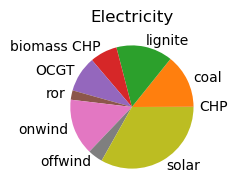

In [47]:
pd.concat([-network.links_t.p1['CHP'], network.generators_t.p], axis=1).sum().plot.pie(figsize=(6, 2), title='Electricity')

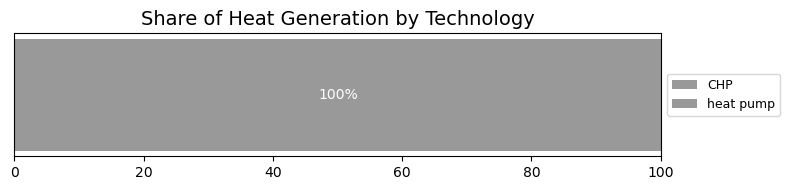

In [51]:
# Combine and sum heat dispatch data
heat_dispatch = pd.concat([
    -network.links_t.p2['CHP'],                  # heat output from CHP
    -network.links_t.p1['heat pump']             # heat output from heat pump
], axis=1).sum()

# Optional: rename "biomass CHP" if present
heat_dispatch = heat_dispatch.rename({"biomass CHP": "biomass"})

# Filter nonzero values
heat_dispatch = heat_dispatch[heat_dispatch > 0]

# Calculate percentages
heat_percent = heat_dispatch / heat_dispatch.sum() * 100

# Get colors for each tech
colors = [color_map.get(tech, "#999999") for tech in heat_percent.index]

# Plot as stacked horizontal bar
fig, ax = plt.subplots(figsize=(8, 2))
left = 0
for i, tech in enumerate(heat_percent.index):
    width = heat_percent[tech]
    ax.barh(0, width, left=left, color=colors[i], label=tech)
    if width > 2:  # Show label only if significant enough
        ax.text(left + width / 2, 0, f"{width:.0f}%", ha='center', va='center', fontsize=10, color="white")
    left += width

# Aesthetics
ax.set_xlim(0, 100)
ax.set_yticks([])
ax.set_title("Share of Heat Generation by Technology", fontsize=14)
ax.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), fontsize=9)
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Heat'}>

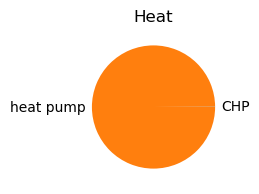

In [48]:
pd.concat([-network.links_t.p2['CHP'],-network.links_t.p1['heat pump']], axis=1).sum().plot.pie(figsize=(6, 2), title='Heat')